# Figure 4 — Coherent Choice-Vigor Strategy Shift

Visualizes the joint strategy shift under threat: subjects simultaneously reduce
high-effort choices and increase vigor on chosen trials. Five panels:

- **A** Dual-axis: P(choose high) decreases while excess effort increases across threat levels
- **B** Scatter: choice_shift vs vigor_shift (anti-correlated)
- **C** Scatter: log(beta) vs delta from joint model (positive coupling)
- **D** Strategy quadrant bar chart: reward and escape rate by median-split groups
- **E** Forest plot: regression coefficients predicting total reward

In [1]:
import sys, warnings
sys.path.insert(0, '/workspace/scripts/plotting')
sys.path.insert(0, '/workspace/scripts')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from scipy import stats
from pathlib import Path

from plotter import Colors, set_plot_style, style_axis, plot_corr

set_plot_style()

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT     = Path('/workspace')
DATA_DIR = ROOT / 'data/exploratory_350/processed/stage5_filtered_data_20260320_191950'
VIGOR_DIR = ROOT / 'data/exploratory_350/processed/vigor_processed'
STAT_DIR = ROOT / 'results/stats'
FIG_DIR  = ROOT / 'results/figs/paper'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Paths set.')

Paths set.


## 1. Load and prepare data

In [2]:
# ── Load behavior ──────────────────────────────────────────────────────────
behavior = pd.read_csv(DATA_DIR / 'behavior.csv')
print(f'behavior: {len(behavior)} trials, {behavior["subj"].nunique()} subjects')

# ── Load feelings (for probe trial filtering) ─────────────────────────────
feelings = pd.read_csv(DATA_DIR / 'feelings.csv')
# Build set of (subj, trialNumber) that are probe trials
probe_trials = feelings[['subj', 'trialNumber']].drop_duplicates()
probe_trials = set(zip(probe_trials['subj'], probe_trials['trialNumber']))
print(f'Probe trial (subj, trial) pairs: {len(probe_trials)}')

# ── Load vigor timeseries and compute trial-level mean vigor ───────────────
vigor_ts = pd.read_parquet(VIGOR_DIR / 'smoothed_vigor_ts.parquet',
                           columns=['subj', 'trial', 'vigor_norm', 'threat', 'choice'])

# Filter out probe trials from vigor
vigor_ts['is_probe'] = vigor_ts.apply(
    lambda r: (r['subj'], r['trial']) in probe_trials, axis=1
)
print(f'Vigor rows before probe filter: {len(vigor_ts)}')
vigor_ts = vigor_ts[~vigor_ts['is_probe']].drop(columns='is_probe')
print(f'Vigor rows after probe filter:  {len(vigor_ts)}')

# Trial-level mean vigor (non-probe trials only)
trial_vigor = (
    vigor_ts
    .groupby(['subj', 'trial', 'threat', 'choice'])['vigor_norm']
    .mean()
    .reset_index()
    .rename(columns={'vigor_norm': 'mean_vigor_norm'})
)
print(f'Trial-level vigor: {len(trial_vigor)} trials')
trial_vigor.head()

behavior: 13185 trials, 293 subjects
Probe trial (subj, trial) pairs: 10546


Vigor rows before probe filter: 3988277
Vigor rows after probe filter:  2081800
Trial-level vigor: 13096 trials


,subj,trial,threat,choice,mean_vigor_norm
0,1,0,0.1,0,0.649351
1,1,2,0.9,0,0.867768
2,1,3,0.5,0,0.713012
3,1,4,0.9,0,0.867769
4,1,6,0.1,0,0.730519


In [3]:
# ── Compute per-subject P(choose high) by threat level ─────────────────────
# choice == 1 means chose high-effort option
choice_by_threat = (
    behavior
    .groupby(['subj', 'threat'])['choice']
    .mean()
    .reset_index()
    .rename(columns={'choice': 'p_high'})
)
print(f'choice_by_threat: {len(choice_by_threat)} rows')

# ── Compute excess effort = vigor_norm - effort_chosen ─────────────────────
# effort_chosen: effort_H if choice==1, effort_L (=0.4 always from task design) if choice==0
# In behavior.csv, effort_H is the high option's effort; low is always 0.4
# Merge behavior info onto trial_vigor
beh_slim = behavior[['subj', 'trial', 'effort_H', 'effort_L']].copy()
# trial in behavior is 1-indexed; trial in vigor is 0-indexed (global event)
# Actually, let's check alignment: behavior 'trial' starts at 1
# vigor 'trial' is global event index 0-80
# The behavior trials are a subset of global events (non-probe only)
# We need to match them. behavior.trial is 1-indexed sequential within behavior rows.
# This won't match vigor trial directly.

# Alternative: compute effort_chosen from trial_vigor's 'choice' column + behavior effort levels
# But trial_vigor already has 'choice'. We need effort_H per trial.
# Let's merge via subj+trial if behavior.trial maps to global event index.

# Check: does behavior.csv trial column match global event index?
print('behavior trial range:', behavior['trial'].min(), '-', behavior['trial'].max())
print('vigor trial range:', trial_vigor['trial'].min(), '-', trial_vigor['trial'].max())

choice_by_threat: 879 rows
behavior trial range: 1 - 45
vigor trial range: 0 - 80


In [4]:
# ── Compute excess effort per trial ────────────────────────────────────────
# Effort_chosen is binary from choice: if choice==1, they chose high-effort option
# effort_H varies per trial (0.6, 0.8, 1.0); effort_L is always 0.4
# We need to get effort_H per (subj, trial) from vigor_ts which has effort_H column

# Reload vigor with effort_H column
vigor_effort = pd.read_parquet(
    VIGOR_DIR / 'smoothed_vigor_ts.parquet',
    columns=['subj', 'trial', 'effort_H']
).drop_duplicates(subset=['subj', 'trial'])

# Merge effort_H onto trial_vigor
trial_vigor = trial_vigor.merge(vigor_effort, on=['subj', 'trial'], how='left')

# effort_chosen: high option effort if choice==1, 0.4 if choice==0
trial_vigor['effort_chosen'] = np.where(
    trial_vigor['choice'] == 1,
    trial_vigor['effort_H'],
    0.4
)

# Excess effort = actual vigor output - required effort
trial_vigor['excess_effort'] = trial_vigor['mean_vigor_norm'] - trial_vigor['effort_chosen']

print(f'Trial vigor with excess effort: {len(trial_vigor)} rows')
print(f'excess_effort: mean={trial_vigor["excess_effort"].mean():.4f}, '
      f'sd={trial_vigor["excess_effort"].std():.4f}')
trial_vigor[['subj', 'trial', 'threat', 'choice', 'mean_vigor_norm', 
             'effort_chosen', 'excess_effort']].head(10)

Trial vigor with excess effort: 13096 rows
excess_effort: mean=0.1132, sd=0.2654


,subj,trial,threat,choice,mean_vigor_norm,effort_chosen,excess_effort
0,1,0,0.1,0,0.649351,0.4,0.249351
1,1,2,0.9,0,0.867768,0.4,0.467768
2,1,3,0.5,0,0.713012,0.4,0.313012
3,1,4,0.9,0,0.867769,0.4,0.467769
4,1,6,0.1,0,0.730519,0.4,0.330519
5,1,8,0.1,0,0.771870,0.4,0.371870
6,1,10,0.9,0,0.750626,0.4,0.350626
7,1,11,0.1,1,0.858233,0.6,0.258233
8,1,12,0.5,0,0.743007,0.4,0.343007
9,1,13,0.5,0,0.830040,0.4,0.430040


In [5]:
# ── Compute per-subject shift metrics ──────────────────────────────────────
# choice_shift = P(high) at T=0.1 minus P(high) at T=0.9  (positive = avoids more under threat)
# vigor_shift  = excess_effort at T=0.9 minus excess_effort at T=0.1  (positive = more vigor under threat)

# Map threat to rounded bins (0.1, 0.5, 0.9)
trial_vigor['threat_bin'] = trial_vigor['threat'].round(1)

# Per-subject excess effort by threat
excess_by_threat = (
    trial_vigor
    .groupby(['subj', 'threat_bin'])['excess_effort']
    .mean()
    .reset_index()
)

# Pivot for shift computation
choice_pivot = choice_by_threat.pivot(index='subj', columns='threat', values='p_high')
excess_pivot = excess_by_threat.pivot(index='subj', columns='threat_bin', values='excess_effort')

# Compute shifts
shifts = pd.DataFrame({
    'subj': choice_pivot.index,
    'choice_shift': choice_pivot[0.1].values - choice_pivot[0.9].values,  # positive = chose less hard at high threat
    'vigor_shift': excess_pivot[0.9].values - excess_pivot[0.1].values,   # positive = more excess vigor at high threat
}).dropna()

print(f'Shift metrics: N={len(shifts)}')
print(f'choice_shift: mean={shifts["choice_shift"].mean():.4f} (should be positive)')
print(f'vigor_shift:  mean={shifts["vigor_shift"].mean():.4f} (should be positive)')

r_shift, p_shift = stats.pearsonr(shifts['choice_shift'], shifts['vigor_shift'])
print(f'r(choice_shift, vigor_shift) = {r_shift:.3f}, p = {p_shift:.4f}')

Shift metrics: N=293
choice_shift: mean=0.4840 (should be positive)
vigor_shift:  mean=0.1568 (should be positive)
r(choice_shift, vigor_shift) = 0.764, p = 0.0000


In [6]:
# ── Load joint model parameters ────────────────────────────────────────────
joint_subj = pd.read_csv(STAT_DIR / 'joint_correlated_subjects.csv')
joint_corr = pd.read_csv(STAT_DIR / 'joint_correlated_correlations.csv')

print(f'Joint model subjects: N={len(joint_subj)}')
print(f'Columns: {joint_subj.columns.tolist()}')
print(f'\nJoint model correlations:')
print(joint_corr.to_string(index=False))

# Prepare log_beta for panel C
joint_subj['log_beta'] = np.log(joint_subj['beta'].clip(lower=1e-6))

# ── Load choice_vigor_dissociation_subjects for quadrant info ──────────────
dissoc = pd.read_csv(STAT_DIR / 'choice_vigor_dissociation_subjects.csv')
print(f'\nDissociation subjects: N={len(dissoc)}')
print(f'Columns: {dissoc.columns.tolist()}')

# Load independently estimated params for validation scatters
separate_params = pd.read_csv(STAT_DIR / 'unified_3param_clean.csv')
separate_params = separate_params.merge(
    joint_subj[['subj', 'delta_ols']], on='subj'
)
print(f'Separate params for validation: N={len(separate_params)}')


Joint model subjects: N=293
Columns: ['subj', 'k', 'k_sd', 'beta', 'beta_sd', 'alpha', 'alpha_sd', 'delta', 'delta_sd', 'delta_ols']

Joint model correlations:
 param_1  param_2  rho_mean  rho_sd  rho_2.5  rho_97.5  P_positive
   log_k log_beta   -0.3356  0.0861  -0.4970   -0.1619      0.0003
   log_k    alpha    0.2216  0.0386   0.1458    0.2993      1.0000
   log_k    delta   -0.3319  0.0559  -0.4396   -0.2222      0.0000
log_beta    alpha   -0.1510  0.0297  -0.2082   -0.0928      0.0000
log_beta    delta    0.2950  0.0502   0.1912    0.3934      1.0000
   alpha    delta   -0.4012  0.0512  -0.4976   -0.2989      0.0000

Dissociation subjects: N=293
Columns: ['subj', 'p_high', 'mean_vigor', 'kappa', 'beta', 'escape_rate', 'total_earnings', 'anx_calib', 'conf_calib', 'trait_anx', 'trait_conf', 'DASS21_Anxiety', 'DASS21_Stress', 'DASS21_Depression', 'OASIS_Total', 'PHQ9_Total', 'AMI_Total', 'MFIS_Physical', 'STICSA_Total', 'choice_z', 'vigor_z', 'quadrant']
Separate params for validatio

In [7]:
# ── Prepare data for Panel D: strategy quadrant bar chart ──────────────────
# Median split on P(choose high) and alpha from joint model
# Merge shifts with joint model params and behavior outcomes

# Compute per-subject total reward and escape rate from behavior
# outcome is binary: 1 = successful foraging, 0 = captured/failed
subj_outcomes = behavior.groupby('subj').agg(
    total_reward=('outcome', 'sum'),
    mean_reward=('outcome', 'mean'),   # == success rate (outcome is 0/1)
).reset_index()
subj_outcomes['escape_rate'] = subj_outcomes['mean_reward']  # same thing for binary outcome

# Merge joint model params with outcomes
quad_df = (
    joint_subj[['subj', 'k', 'beta', 'alpha', 'delta', 'log_beta']]
    .merge(subj_outcomes, on='subj', how='inner')
)

# Median split on P(choose high) and alpha
subj_p_high = behavior.groupby('subj')['choice'].mean().reset_index().rename(columns={'choice': 'p_high'})
quad_df = quad_df.merge(subj_p_high, on='subj', how='inner')

quad_df['choice_group'] = np.where(quad_df['p_high'] >= quad_df['p_high'].median(), 'High P(hard)', 'Low P(hard)')
quad_df['alpha_group'] = np.where(quad_df['alpha'] >= quad_df['alpha'].median(), 'High alpha', 'Low alpha')
quad_df['quadrant'] = quad_df['choice_group'] + '\n' + quad_df['alpha_group']

# Compute mean total reward per quadrant (sum across 45 trials)
quad_summary = quad_df.groupby('quadrant').agg(
    n=('subj', 'count'),
    mean_total_reward=('total_reward', 'mean'),
    se_total_reward=('total_reward', 'sem'),
    mean_escape=('escape_rate', 'mean'),
    se_escape=('escape_rate', 'sem'),
).reset_index()

print('Strategy quadrant summary:')
print(quad_summary.to_string(index=False))

Strategy quadrant summary:
                quadrant   n  mean_total_reward  se_total_reward  mean_escape  se_escape
High P(hard)\nHigh alpha  51          13.039216         0.805842     0.289760   0.017908
 High P(hard)\nLow alpha 106          17.462264         0.513112     0.388050   0.011402
 Low P(hard)\nHigh alpha  96          10.864583         0.669613     0.241435   0.014880
  Low P(hard)\nLow alpha  40          15.475000         0.933691     0.343889   0.020749


In [8]:
# ── Prepare data for Panel E: multiple regression ──────────────────────────
# Predict total reward from alpha, delta, k, log_beta (all z-scored)

reg_df = quad_df.dropna(subset=['alpha', 'delta', 'k', 'log_beta', 'mean_reward']).copy()
predictors = ['alpha', 'delta', 'k', 'log_beta']
pred_labels = [r'$\alpha$', r'$\delta$', r'$\kappa$', r'$\log(\beta)$']

# Z-score predictors
for col in predictors:
    reg_df[col + '_z'] = stats.zscore(reg_df[col].values)

dv = reg_df['mean_reward'].values
X = np.column_stack([reg_df[col + '_z'].values for col in predictors])
X = np.hstack([np.ones((len(X), 1)), X])  # intercept

# OLS
from numpy.linalg import lstsq
beta_hat, _, rank, _ = lstsq(X, dv, rcond=None)
y_hat = X @ beta_hat
ss_res = np.sum((dv - y_hat) ** 2)
ss_tot = np.sum((dv - dv.mean()) ** 2)
r_sq = 1 - ss_res / ss_tot
n, p = X.shape
sigma2 = ss_res / (n - p)
cov_mat = sigma2 * np.linalg.pinv(X.T @ X)
se_hat = np.sqrt(np.diag(cov_mat))
t_hat = beta_hat / se_hat
p_hat = 2 * stats.t.sf(np.abs(t_hat), df=n - p)

# 95% CI
tcrit = stats.t.ppf(0.975, df=n - p)
ci_lo = beta_hat - tcrit * se_hat
ci_hi = beta_hat + tcrit * se_hat

# Store regression results (skip intercept)
reg_results = pd.DataFrame({
    'predictor': pred_labels,
    'beta': beta_hat[1:],
    'se': se_hat[1:],
    'ci_lo': ci_lo[1:],
    'ci_hi': ci_hi[1:],
    't': t_hat[1:],
    'p': p_hat[1:],
})

print(f'Regression R-squared = {r_sq:.4f}, N = {n}')
print(reg_results.to_string(index=False))

Regression R-squared = 0.3161, N = 293
    predictor      beta       se     ci_lo     ci_hi         t            p
     $\alpha$ -0.062085 0.007619 -0.077081 -0.047089 -8.148577 1.134509e-14
     $\delta$ -0.032470 0.010948 -0.054018 -0.010923 -2.965993 3.269820e-03
     $\kappa$ -0.028096 0.008436 -0.044699 -0.011493 -3.330695 9.792559e-04
$\log(\beta)$ -0.033736 0.011058 -0.055500 -0.011972 -3.050909 2.494060e-03


## 2. Figure 4 — Multi-panel figure

In [9]:
# ── Helper: consistent axis polish ─────────────────────────────────────────
def polish_ax(ax, xlabel=None, ylabel=None):
    """Apply plotter.py-consistent styling to an axis."""
    ax.set_facecolor('#FCFCFD')
    ax.spines['left'].set_color('#D1D5DB')
    ax.spines['bottom'].set_color('#E5E7EB')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.tick_params(axis='both', colors=Colors.INK, labelsize=9, length=4)
    ax.grid(True, axis='y', color=Colors.GREY, alpha=0.55, linewidth=0.8)
    ax.grid(False, axis='x')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color=Colors.INK)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color=Colors.INK)

def panel_label(ax, label, x=-0.15, y=1.08):
    """Add bold panel label (A, B, C, ...) to axis."""
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', color=Colors.DARK_GREY,
            va='top', ha='left')

print('Helpers defined.')

Helpers defined.


Saved: /workspace/results/figs/paper/fig4_coherent_shift.pdf
Saved: /workspace/results/figs/paper/fig4_coherent_shift.png


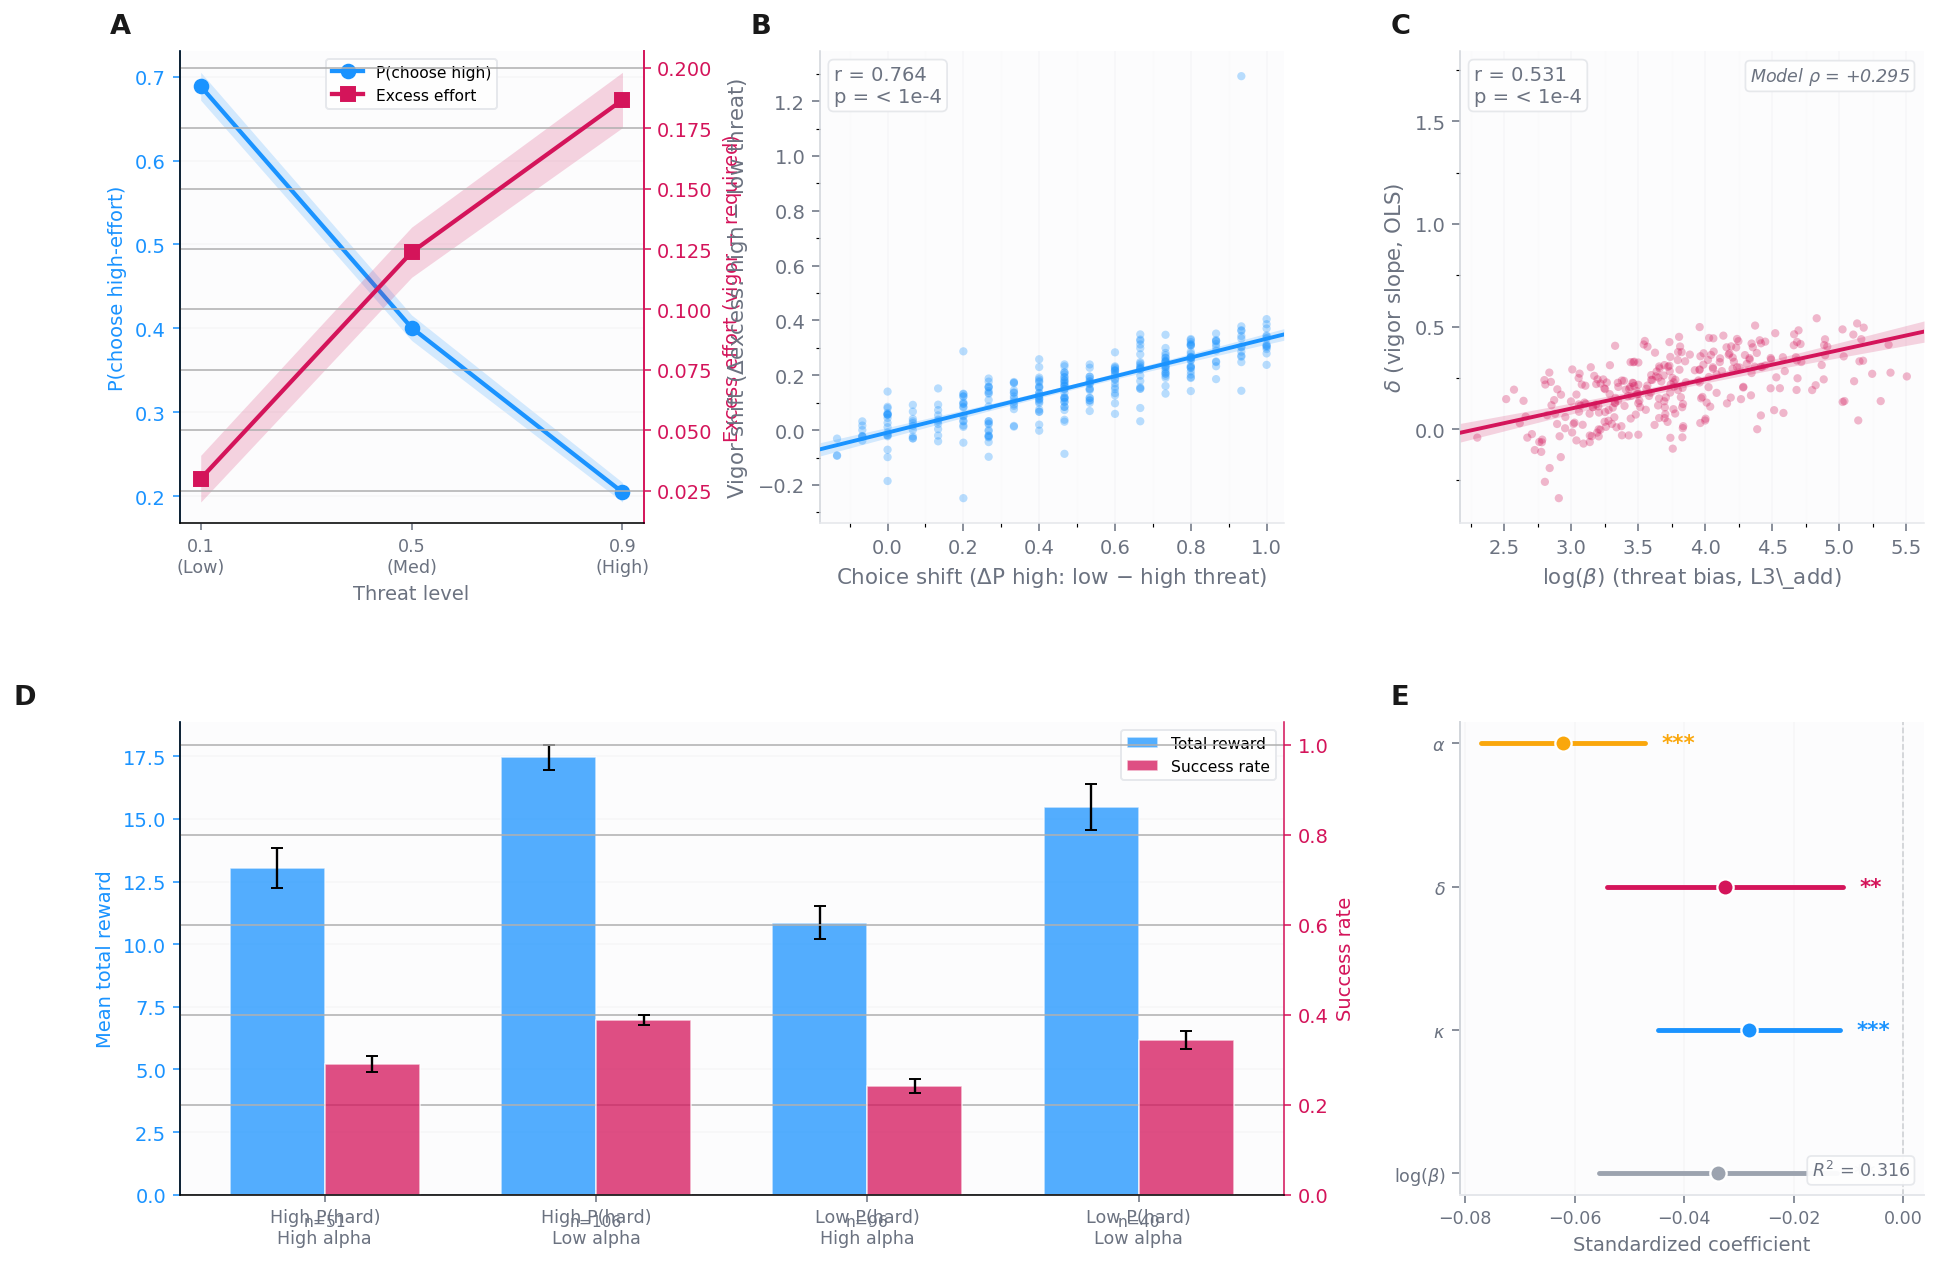

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Coherent choice-vigor strategy shift
# ══════════════════════════════════════════════════════════════════════════
set_plot_style()

fig = plt.figure(figsize=(14, 9.5), facecolor='white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                       left=0.07, right=0.96, top=0.94, bottom=0.08)

# ── Panel A: Dual-axis line plot ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])

threat_levels = [0.1, 0.5, 0.9]

# P(choose high) by threat — per-subject means already computed
mean_ph = choice_by_threat.groupby('threat')['p_high'].mean()
sem_ph = choice_by_threat.groupby('threat')['p_high'].sem()

# Excess effort by threat — per-subject means
excess_by_t = trial_vigor.groupby(['subj', 'threat_bin'])['excess_effort'].mean().reset_index()
mean_ee = excess_by_t.groupby('threat_bin')['excess_effort'].mean()
sem_ee = excess_by_t.groupby('threat_bin')['excess_effort'].sem()

# Left axis: P(choose high) — cerulean
color_choice = Colors.CERULEAN2
ax_a.plot(threat_levels, [mean_ph.get(t, np.nan) for t in threat_levels],
          'o-', color=color_choice, lw=2.2, ms=7, zorder=3, label='P(choose high)')
ax_a.fill_between(
    threat_levels,
    [mean_ph.get(t, 0) - sem_ph.get(t, 0) for t in threat_levels],
    [mean_ph.get(t, 0) + sem_ph.get(t, 0) for t in threat_levels],
    color=color_choice, alpha=0.18, linewidth=0
)
ax_a.set_ylabel('P(choose high-effort)', fontsize=10, color=color_choice)
ax_a.tick_params(axis='y', labelcolor=color_choice, colors=color_choice)
ax_a.set_xlabel('Threat level', fontsize=10, color=Colors.INK)
ax_a.set_xticks(threat_levels)
ax_a.set_xticklabels(['0.1\n(Low)', '0.5\n(Med)', '0.9\n(High)'], fontsize=9)

# Right axis: Excess effort — ruby
ax_a2 = ax_a.twinx()
color_vigor = Colors.RUBY1
ax_a2.plot(threat_levels, [mean_ee.get(t, np.nan) for t in threat_levels],
           's-', color=color_vigor, lw=2.2, ms=7, zorder=3, label='Excess effort')
ax_a2.fill_between(
    threat_levels,
    [mean_ee.get(t, 0) - sem_ee.get(t, 0) for t in threat_levels],
    [mean_ee.get(t, 0) + sem_ee.get(t, 0) for t in threat_levels],
    color=color_vigor, alpha=0.18, linewidth=0
)
ax_a2.set_ylabel('Excess effort (vigor $-$ required)', fontsize=10, color=color_vigor)
ax_a2.tick_params(axis='y', labelcolor=color_vigor, colors=color_vigor)
ax_a2.spines['right'].set_color(color_vigor)
ax_a2.spines['right'].set_visible(True)
ax_a2.spines['right'].set_linewidth(1)
ax_a2.spines['top'].set_visible(False)

# Style left axis
ax_a.set_facecolor('#FCFCFD')
ax_a.spines['left'].set_color(color_choice)
ax_a.spines['bottom'].set_color('#E5E7EB')
ax_a.spines['right'].set_visible(False)
ax_a.spines['top'].set_visible(False)
ax_a.tick_params(axis='x', colors=Colors.INK, labelsize=9)
ax_a.grid(True, axis='y', color=Colors.GREY, alpha=0.35, linewidth=0.8)
ax_a.grid(False, axis='x')

# Combined legend
lines_a = ax_a.get_lines() + ax_a2.get_lines()
labels_a = [l.get_label() for l in lines_a]
ax_a.legend(lines_a, labels_a, loc='upper center', fontsize=8,
            frameon=True, facecolor='white', edgecolor='#E5E7EB',
            framealpha=0.95, ncol=1, borderpad=0.4)

panel_label(ax_a, 'A')

# ── Panel B: choice_shift vs vigor_shift scatter ──────────────────────────
ax_b = fig.add_subplot(gs[0, 1])

_, stats_b = plot_corr(
    shifts['choice_shift'].values, shifts['vigor_shift'].values,
    colorset_hex=Colors.CERULEAN2, point_alpha=0.3, point_size=18,
    xlabel=r'Choice shift ($\Delta$P high: low $-$ high threat)',
    ylabel=r'Vigor shift ($\Delta$excess: high $-$ low threat)',
    ax=ax_b
)
panel_label(ax_b, 'B')

# ── Panel C: log(beta) vs delta (independent est.) ─────────────────────────
ax_c = fig.add_subplot(gs[0, 2])

_, stats_c = plot_corr(
    np.log(separate_params['beta'].values + 1e-6), separate_params['delta_ols'].values,
    colorset_hex=Colors.RUBY1, point_alpha=0.3, point_size=18,
    xlabel=r'$\log(\beta)$ (threat bias, L3\_add)',
    ylabel=r'$\delta$ (vigor slope, OLS)',
    ax=ax_c
)
# Add model rho annotation
rho_row = joint_corr[
    (joint_corr['param_1'] == 'log_beta') & (joint_corr['param_2'] == 'delta')
]
if len(rho_row):
    rho_val = rho_row['rho_mean'].values[0]
    ax_c.text(0.97, 0.97,
              f'Model $\\rho$ = {rho_val:+.3f}',
              transform=ax_c.transAxes, va='top', ha='right',
              fontsize=9, color=Colors.INK, fontstyle='italic',
              bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                        edgecolor='#E5E7EB', linewidth=0.9, alpha=0.95))
panel_label(ax_c, 'C')

# ── Panel D: Strategy quadrant bar chart ──────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0:2])

# Sort quadrants in a logical order
quad_order = [
    'High P(hard)\nHigh alpha', 'High P(hard)\nLow alpha',
    'Low P(hard)\nHigh alpha', 'Low P(hard)\nLow alpha',
]
# Reindex safely — only keep quadrants that exist
existing = [q for q in quad_order if q in quad_summary['quadrant'].values]
quad_summary_sorted = quad_summary.set_index('quadrant').loc[existing].reset_index()

x_pos = np.arange(len(quad_summary_sorted))
bar_w = 0.35

# Total reward bars
bars1 = ax_d.bar(x_pos - bar_w/2, quad_summary_sorted['mean_total_reward'],
                 bar_w, yerr=quad_summary_sorted['se_total_reward'],
                 color=Colors.CERULEAN2, alpha=0.75, edgecolor='white',
                 linewidth=0.8, capsize=3, error_kw={'lw': 1.2, 'color': Colors.INK},
                 label='Total reward', zorder=2)

# Success rate bars (on twin axis)
ax_d2 = ax_d.twinx()
bars2 = ax_d2.bar(x_pos + bar_w/2, quad_summary_sorted['mean_escape'],
                  bar_w, yerr=quad_summary_sorted['se_escape'],
                  color=Colors.RUBY1, alpha=0.75, edgecolor='white',
                  linewidth=0.8, capsize=3, error_kw={'lw': 1.2, 'color': Colors.INK},
                  label='Success rate', zorder=2)

ax_d.set_xticks(x_pos)
ax_d.set_xticklabels(quad_summary_sorted['quadrant'].values, fontsize=9, color=Colors.INK)
ax_d.set_ylabel('Mean total reward', fontsize=10, color=Colors.CERULEAN2)
ax_d.tick_params(axis='y', labelcolor=Colors.CERULEAN2, colors=Colors.CERULEAN2)
ax_d2.set_ylabel('Success rate', fontsize=10, color=Colors.RUBY1)
ax_d2.tick_params(axis='y', labelcolor=Colors.RUBY1, colors=Colors.RUBY1)
ax_d2.set_ylim(0, 1.05)

# Add N labels below bars
ylim_d = ax_d.get_ylim()
for idx, (_, row) in enumerate(quad_summary_sorted.iterrows()):
    ax_d.text(x_pos[idx], ylim_d[0] - 0.04 * (ylim_d[1] - ylim_d[0]),
              f'n={int(row["n"])}', ha='center', va='top', fontsize=8, color=Colors.INK)

# Style
ax_d.set_facecolor('#FCFCFD')
ax_d.spines['left'].set_color(Colors.CERULEAN2)
ax_d.spines['bottom'].set_color('#E5E7EB')
ax_d.spines['right'].set_visible(False)
ax_d.spines['top'].set_visible(False)
ax_d2.spines['right'].set_color(Colors.RUBY1)
ax_d2.spines['right'].set_visible(True)
ax_d2.spines['top'].set_visible(False)
ax_d.grid(True, axis='y', color=Colors.GREY, alpha=0.35, linewidth=0.8)
ax_d.grid(False, axis='x')
ax_d.tick_params(axis='x', colors=Colors.INK, labelsize=9)

# Legend
ax_d.legend([bars1, bars2], ['Total reward', 'Success rate'],
            loc='upper right', fontsize=8, frameon=True,
            facecolor='white', edgecolor='#E5E7EB', framealpha=0.95)

panel_label(ax_d, 'D')

# ── Panel E: Forest plot — regression coefficients ────────────────────────
ax_e = fig.add_subplot(gs[1, 2])

y_pos = np.arange(len(reg_results))
colors_e = [Colors.PERSIMMON3, Colors.RUBY1, Colors.CERULEAN2, Colors.SLATE]

for i, (_, row) in enumerate(reg_results.iterrows()):
    # CI whisker
    ax_e.plot([row['ci_lo'], row['ci_hi']], [y_pos[i], y_pos[i]],
              color=colors_e[i], lw=2.5, solid_capstyle='round', zorder=2)
    # Point estimate
    ax_e.scatter(row['beta'], y_pos[i], s=70, color=colors_e[i],
                 edgecolors='white', linewidths=1.2, zorder=3)
    # Significance stars
    if row['p'] < 0.001:
        sig_str = '***'
    elif row['p'] < 0.01:
        sig_str = '**'
    elif row['p'] < 0.05:
        sig_str = '*'
    else:
        sig_str = ''
    if sig_str:
        ax_e.text(row['ci_hi'] + 0.003, y_pos[i], sig_str,
                  va='center', ha='left', fontsize=11, color=colors_e[i], fontweight='bold')

# Zero reference line
ax_e.axvline(0, color=Colors.INK, lw=0.8, ls='--', alpha=0.4, zorder=1)

ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(reg_results['predictor'].values, fontsize=11)
ax_e.invert_yaxis()

polish_ax(ax_e, xlabel='Standardized coefficient')
ax_e.set_ylabel('')
ax_e.grid(False, axis='y')
ax_e.grid(True, axis='x', color=Colors.GREY, alpha=0.35, linewidth=0.8)

# Add R-squared annotation
ax_e.text(0.97, 0.03, f'$R^2$ = {r_sq:.3f}',
          transform=ax_e.transAxes, va='bottom', ha='right',
          fontsize=9, color=Colors.INK,
          bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                    edgecolor='#E5E7EB', linewidth=0.9, alpha=0.95))

panel_label(ax_e, 'E')

# ── Save ──────────────────────────────────────────────────────────────────
fig.savefig(FIG_DIR / 'fig4_coherent_shift.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig4_coherent_shift.png', dpi=300, bbox_inches='tight')
print(f'Saved: {FIG_DIR}/fig4_coherent_shift.pdf')
print(f'Saved: {FIG_DIR}/fig4_coherent_shift.png')
plt.show()